In [1]:
# ==========================================
# PROJECT 1 - ADVANCED EDA & FEATURE ENGINEERING
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from scipy.stats import zscore

In [2]:
# ------------------------------------------
# Load Dataset
# ------------------------------------------

df=pd.read_csv("Titanic-Dataset.csv")

print("First 5 Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

In [3]:
# ------------------------------------------
# Check Missing Values
# ------------------------------------------

print("\nMissing Values")
print(df.isnull().sum())


Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# ------------------------------------------
# Remove Duplicate Rows
# ------------------------------------------

duplicates=df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df=df.drop_duplicates()


Duplicate Rows: 0


In [6]:
# ------------------------------------------
# Handle Missing Values
# ------------------------------------------

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Cabin"] = df["Cabin"].fillna("Unknown")

print("\nMissing Values After Cleaning")
print(df.isnull().sum())


Missing Values After Cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [7]:
# ------------------------------------------
# KNN Imputation Example
# ------------------------------------------

knn_df=df.copy()
knn_columns=["Age", "Fare"]
imputer=KNNImputer(n_neighbors=5)
knn_df[knn_columns]=imputer.fit_transform(knn_df[knn_columns])
print("\nKNN Imputation Completed")


KNN Imputation Completed


In [8]:
# ------------------------------------------
# Outlier Detection Using Z Score
# ------------------------------------------

df["Fare_Z"]=zscore(df["Fare"])

outliers=df[np.abs(df["Fare_Z"]) > 3]

print("\nNumber of Outliers (Z Score):")
print(len(outliers))



Number of Outliers (Z Score):
20


In [9]:
# ------------------------------------------
# Outlier Detection Using IQR
# ------------------------------------------

Q1=df["Fare"].quantile(0.25)
Q3=df["Fare"].quantile(0.75)

IQR=Q3-Q1

lower=Q1 - 1.5 * IQR
upper=Q3 + 1.5 * IQR

clean_df=df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

print("\nDataset Shape Before Removing Outliers")
print(df.shape)

print("\nDataset Shape After Removing Outliers")
print(clean_df.shape)


Dataset Shape Before Removing Outliers
(891, 13)

Dataset Shape After Removing Outliers
(775, 13)


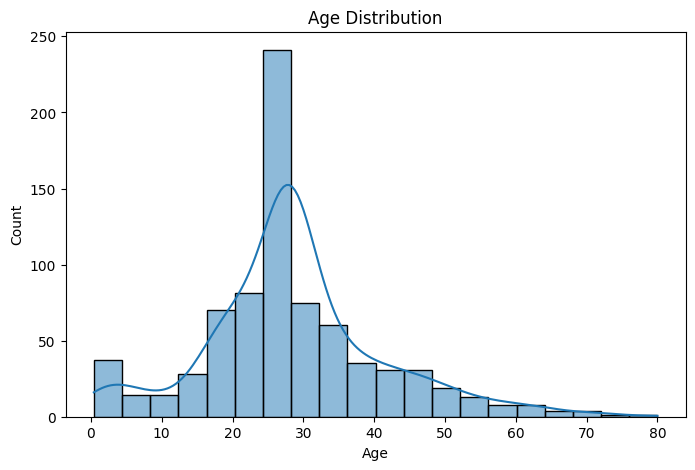

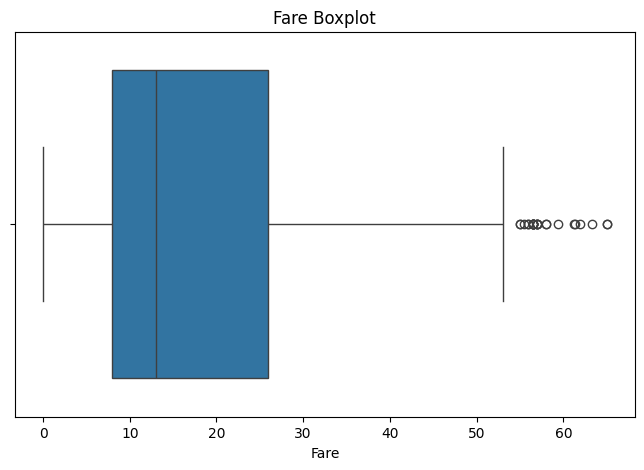

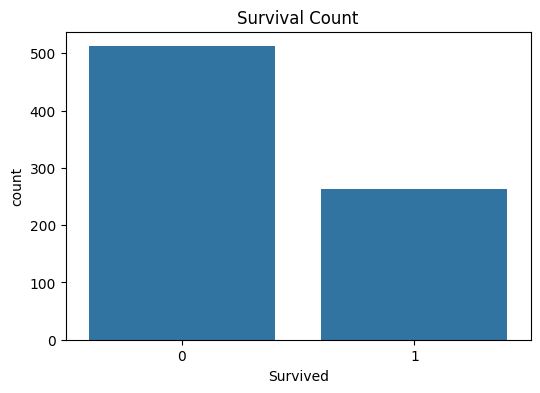

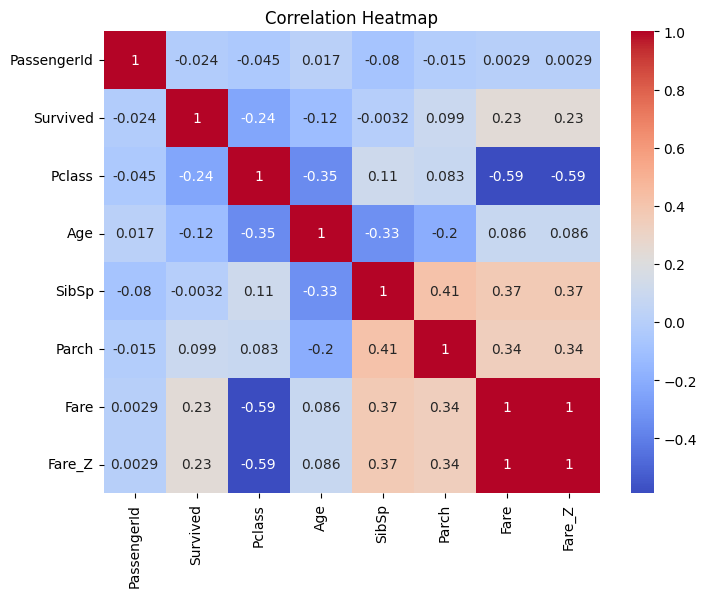

In [10]:
# ------------------------------------------
# Exploratory Data Analysis
# ------------------------------------------

plt.figure(figsize=(8,5))
sns.histplot(clean_df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=clean_df["Fare"])
plt.title("Fare Boxplot")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=clean_df)
plt.title("Survival Count")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(clean_df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
# ------------------------------------------
# Feature Engineering
# ------------------------------------------

clean_df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)].copy()
clean_df["FamilySize"] = clean_df["SibSp"] + clean_df["Parch"] + 1

clean_df["IsAlone"] = np.where(clean_df["FamilySize"] == 1, 1, 0)

clean_df["FarePerPerson"] = clean_df["Fare"] / clean_df["FamilySize"]

clean_df["AgeGroup"] = pd.cut(clean_df["Age"],bins=[0,18,35,60,100],labels=["Child","Young Adult","Adult","Senior"])

print("\nNew Features Created")
print(clean_df[["FamilySize","IsAlone","FarePerPerson","AgeGroup"]].head())



New Features Created
   FamilySize  IsAlone  FarePerPerson     AgeGroup
0           2        0         3.6250  Young Adult
2           1        1         7.9250  Young Adult
3           2        0        26.5500  Young Adult
4           1        1         8.0500  Young Adult
5           1        1         8.4583  Young Adult


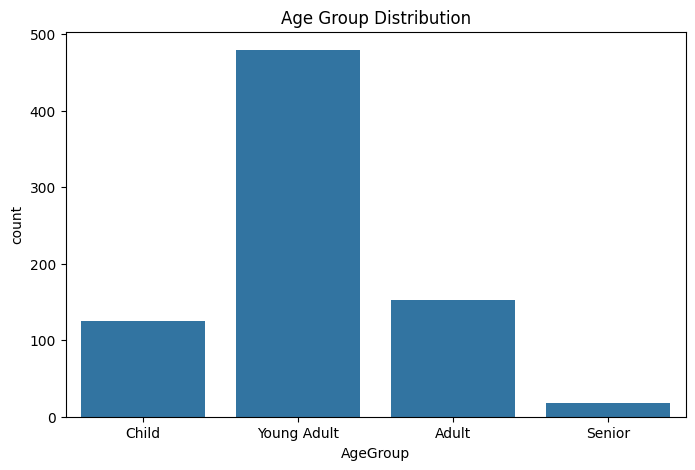

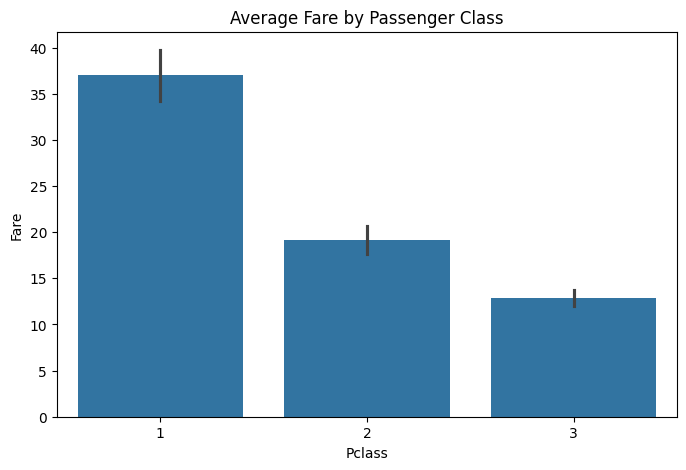

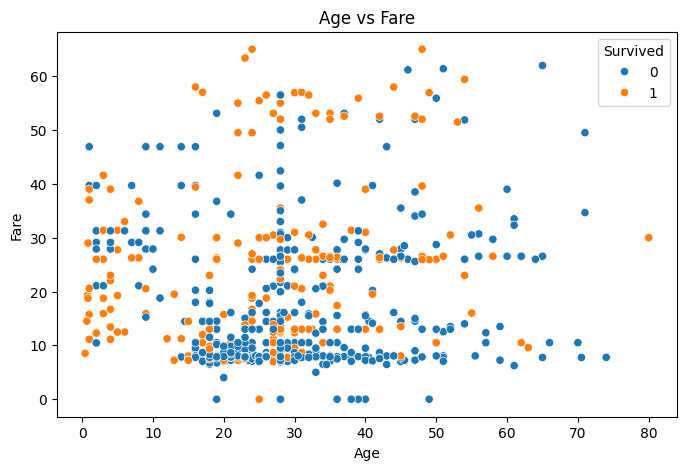

In [14]:
# ------------------------------------------
# More Visualizations
# ------------------------------------------

plt.figure(figsize=(8,5))
sns.countplot(x="AgeGroup", data=clean_df)
plt.title("Age Group Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="Pclass",
            y="Fare",
            data=clean_df)
plt.title("Average Fare by Passenger Class")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="Age",y="Fare",hue="Survived",data=clean_df)

plt.title("Age vs Fare")
plt.show()

In [15]:
# ------------------------------------------
# Save Clean Dataset
# ------------------------------------------

clean_df.to_csv("Clean_Titanic_Dataset.csv", index=False)

print("\nClean Dataset Saved Successfully!")


Clean Dataset Saved Successfully!


In [16]:
# ------------------------------------------
# Final Information
# ------------------------------------------

print("\nFinal Dataset")
print(clean_df.head())

print("\nFinal Shape")
print(clean_df.shape)

print("\nProject Completed Successfully!")


Final Dataset
   PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                       Braund, Mr. Owen Harris    male  22.0      1      0   
2                        Heikkinen, Miss. Laina  female  26.0      0      0   
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0   
4                      Allen, Mr. William Henry    male  35.0      0      0   
5                              Moran, Mr. James    male  28.0      0      0   

             Ticket     Fare    Cabin Embarked    Fare_Z  FamilySize  IsAlone  \
0         A/5 21171   7.2500  Unknown        S -0.502445           2        0   
2  STON/O2. 3101282   7.9250  Unknown        S -0.488854           1        1   
3            113803  53.1000     C123        S  0.